Problem Statement - HELP International CEO needs to strategically focus on the countries in dire need of aid. We need to classify them using K_Means and give a final list of countries that must be provided aid using the dataset provided

Analysis approach - check the data, conduct null removal/imputation if necessary. Conduct univariate/bivariate analysis and outlier analysis as well. I would not prefer to remove outliers since the countries in direst need of aid would usually have significant outliers in terms of socio-economic variables.
Use K-Means algorithm, first i would select the ideal value of k and then run the model. Using elbow curve method and using silhoutte score i would be selecting the ideal value of k. After identifying the clusters, i would be able to run analysis on the clusters provided and give a final list of countries that would be in direst need of aid.

In [131]:
# Filtering out the warnings

import warnings

warnings.filterwarnings('ignore')

In [132]:
# Importing  required libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [133]:
# Loading the dataset

df = pd.read_csv("Country-data.csv")

In [134]:
# Having a look at the first 10 rows

df.head(10)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840


In [135]:
# Checking the number of rows and columns

df.shape

(167, 10)

In [136]:
# Checking the column names as a list

df.columns.to_list()

['country',
 'child_mort',
 'exports',
 'health',
 'imports',
 'income',
 'inflation',
 'life_expec',
 'total_fer',
 'gdpp']

In [137]:
# Checking info regarding India out of curiosity

df[df['country'] == 'India']

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
69,India,58.8,22.6,4.05,27.1,4410,8.98,66.2,2.6,1350


In [138]:
# Column wise description of dataset

df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [139]:
# Checking info regarding the country with the highest child mortality

df[df['child_mort'] == 208.000000]

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
66,Haiti,208.0,15.3,6.91,64.7,1500,5.45,32.1,3.33,662


In [140]:
# Checking info regarding the country with the highest exports

df[df['exports'] == 200.000000]

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
133,Singapore,2.8,200.0,3.96,174.0,72100,-0.046,82.7,1.15,46600


In [141]:
# Checking whether there are any null values in any columns

df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


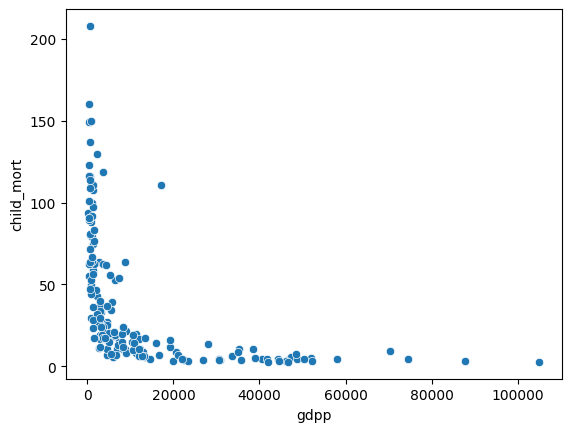

In [142]:
# Plotting bivariate analysis of gdpp vs child mortality

sns.scatterplot(data = df, x = 'gdpp', y = 'child_mort')
plt.show()

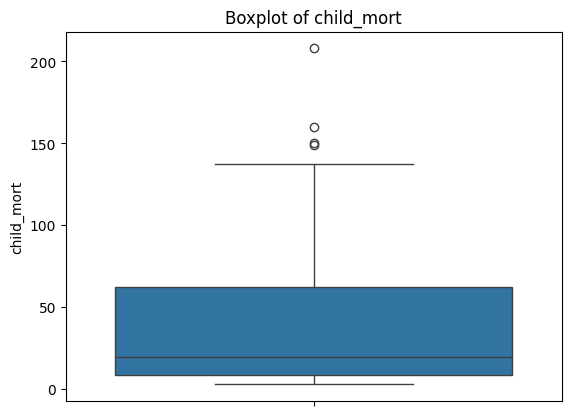

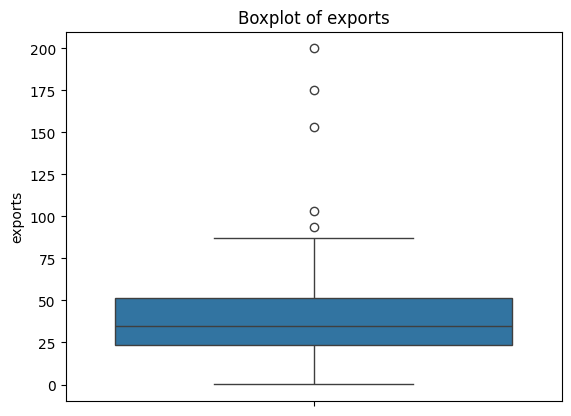

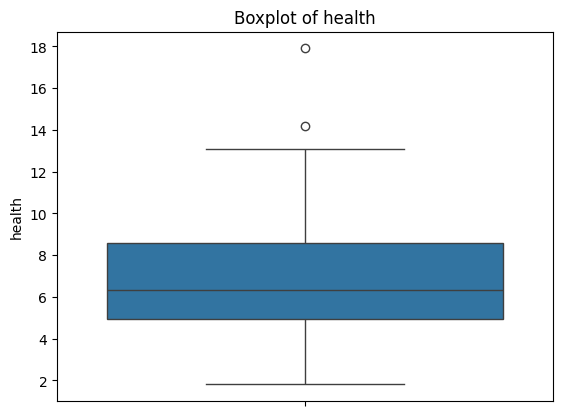

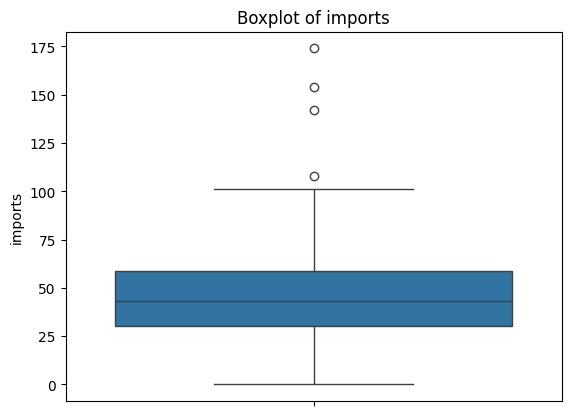

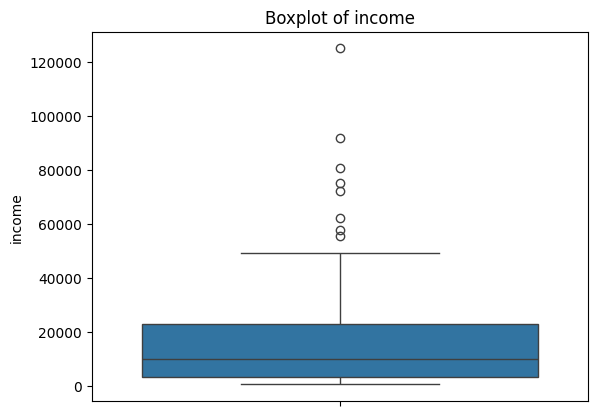

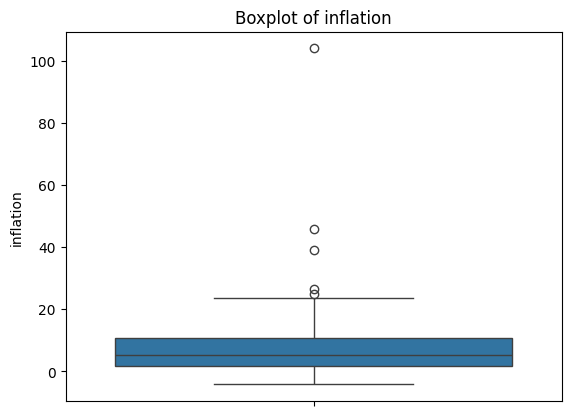

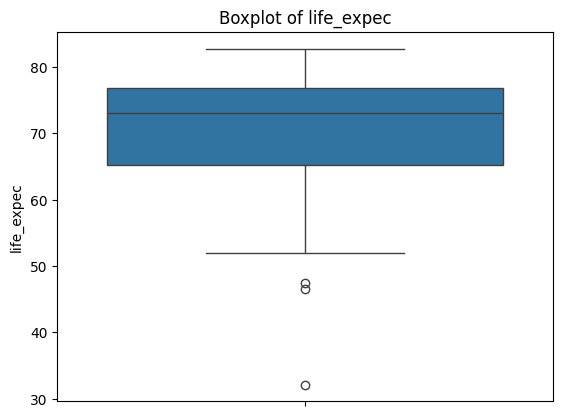

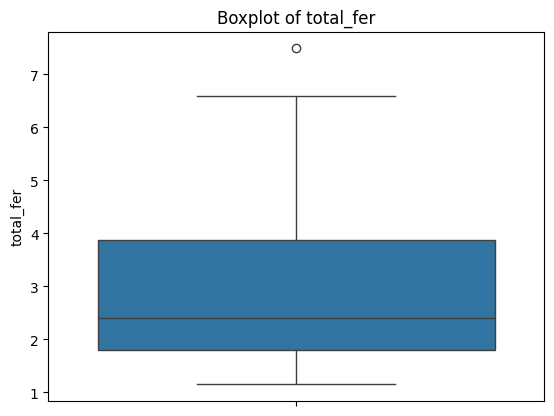

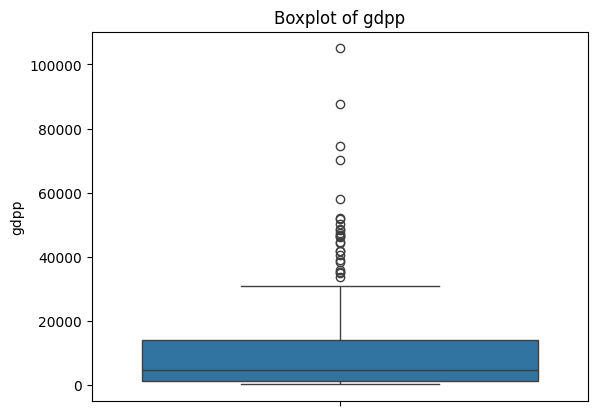

In [143]:
# Plotting boxplots of various columns except country

columns = ['child_mort',
 'exports',
 'health',
 'imports',
 'income',
 'inflation',
 'life_expec',
 'total_fer',
 'gdpp']

for col in columns:
  sns.boxplot(data = df, y = col)
  plt.title(f'Boxplot of {col}')
  plt.show()

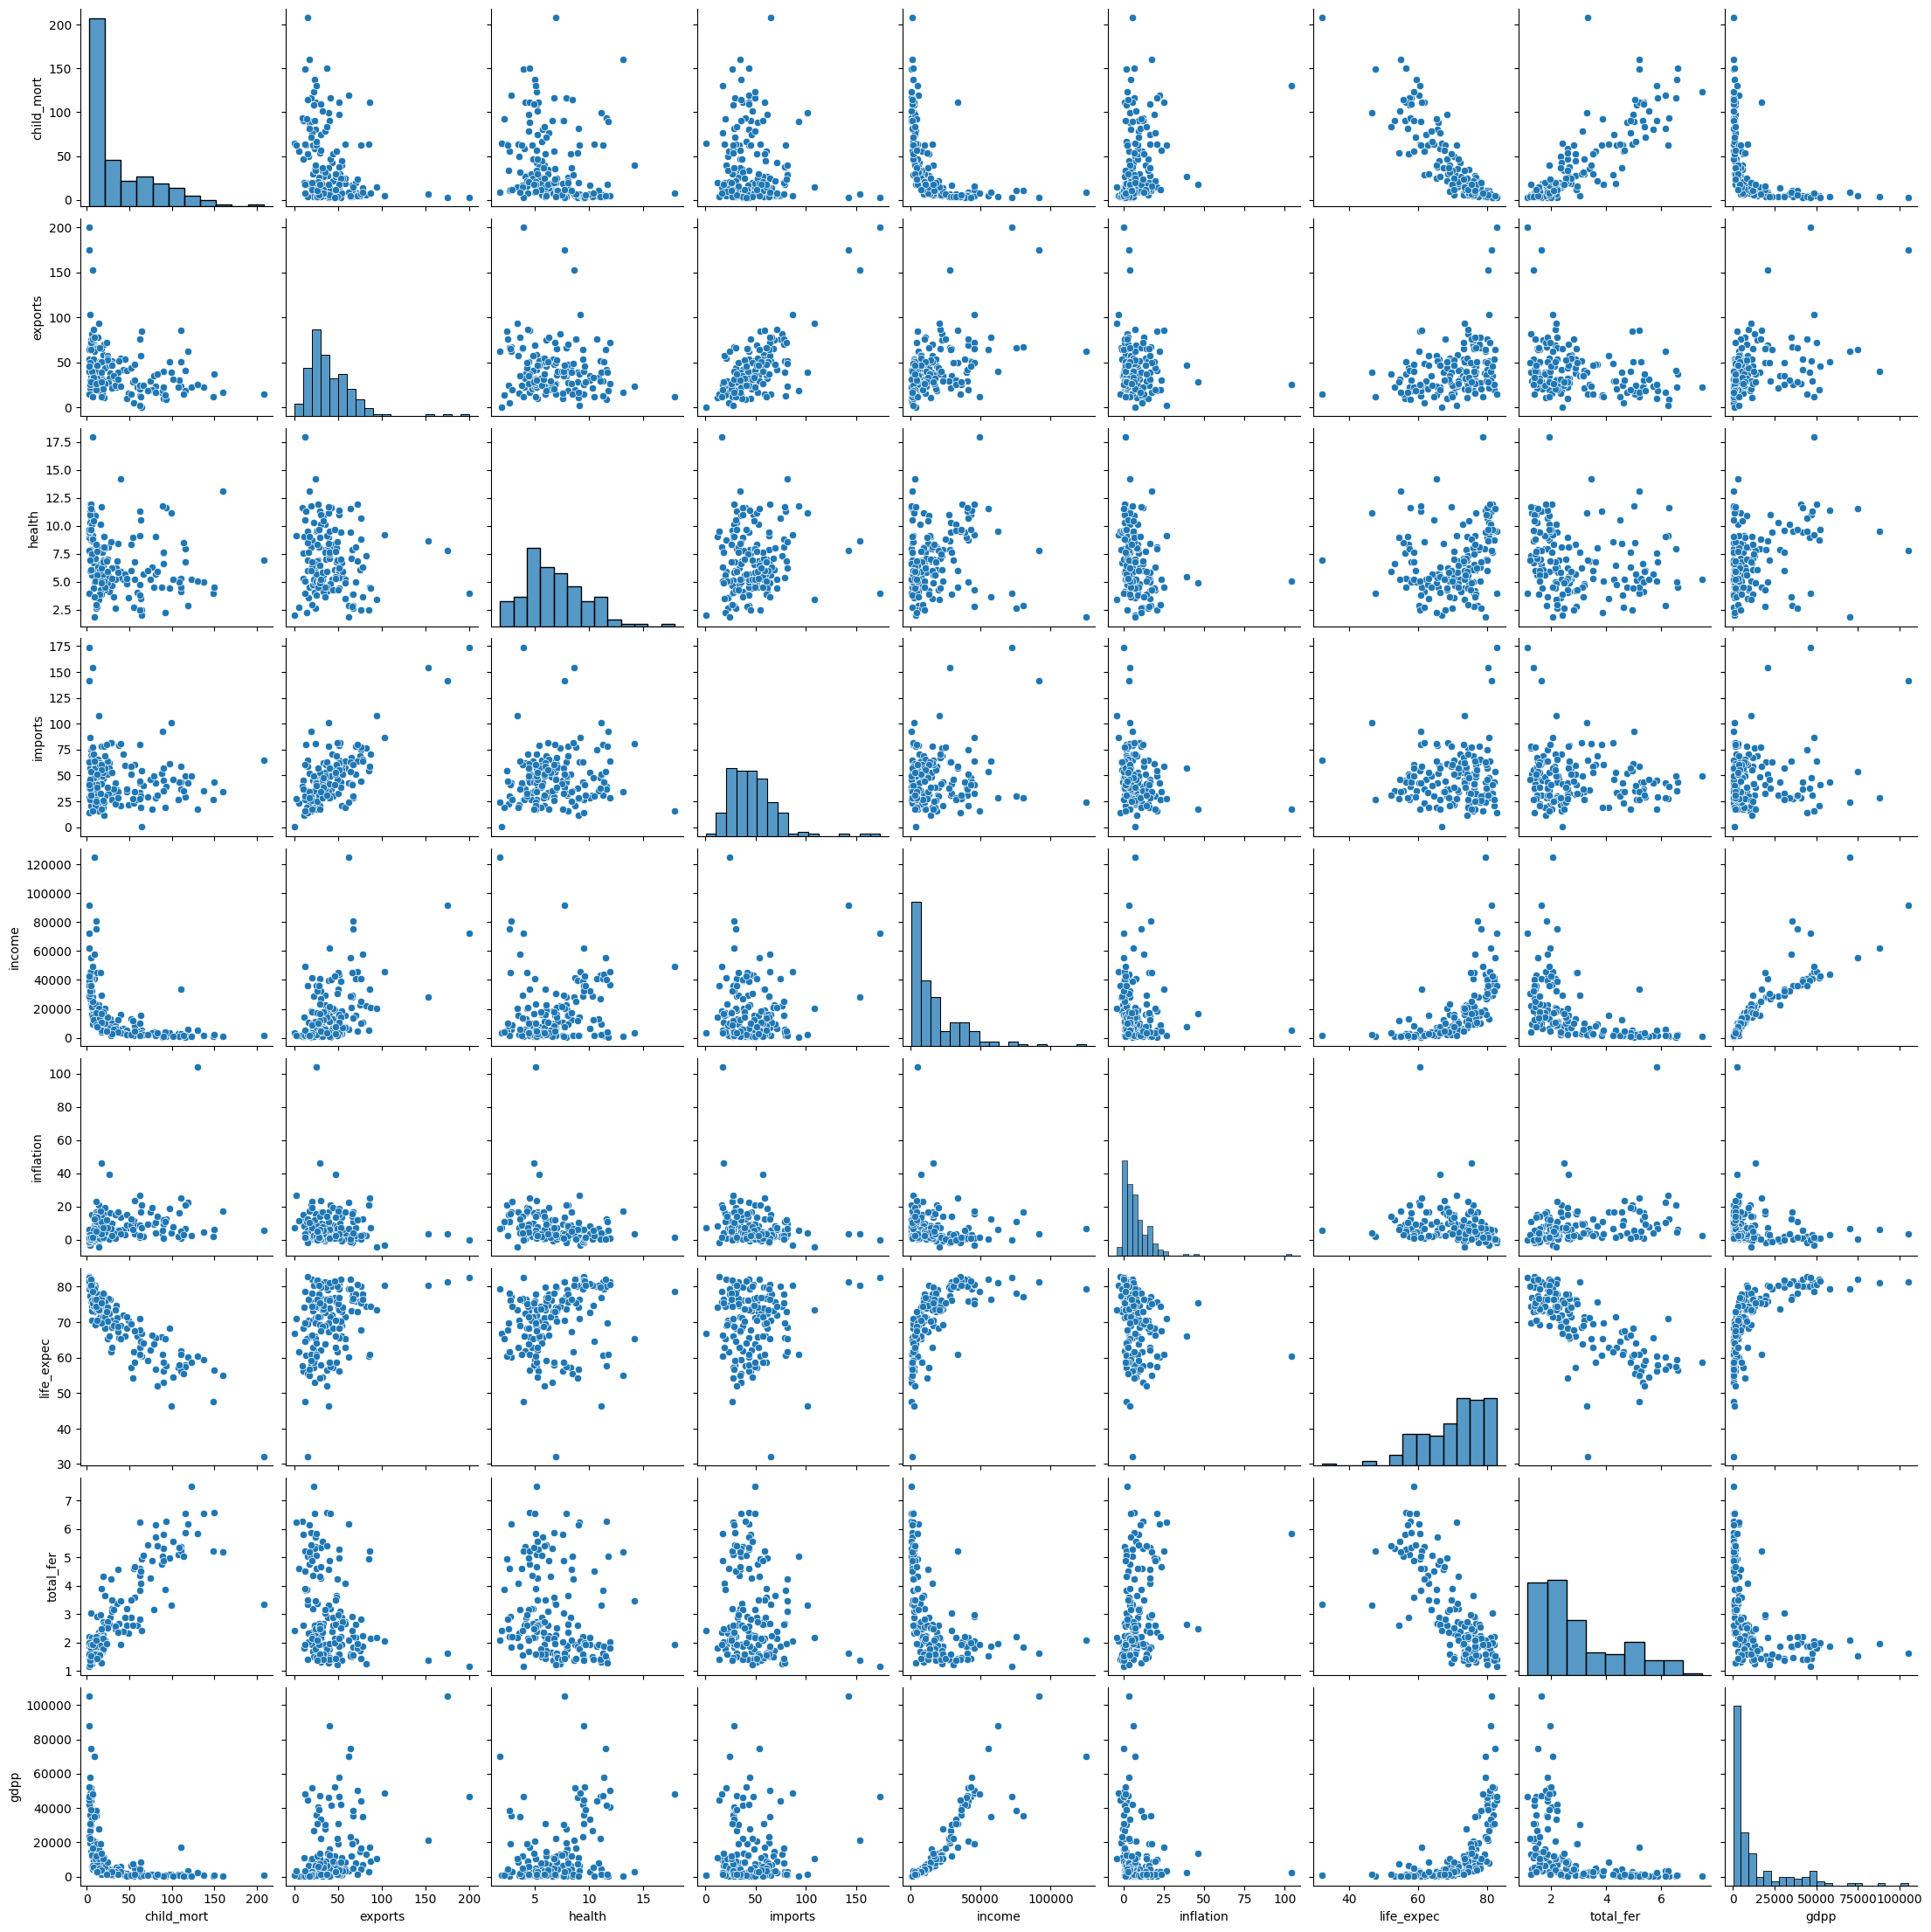

In [144]:
# Now we will find bivariate relationships between all the variables together

sns.pairplot(df)

Above plots allow us to find linear relationships between different variables

In [145]:
# Removing the categorical variable 'country' for scaling purposes

df_clustering = df.drop('country', axis = 1)
df_clustering

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...
162,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [146]:
# instantiating and implementing standard scaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clustering)

In [147]:
sse = []
for k in range(1,11):
	km = KMeans(n_clusters=k, random_state=2)
	km.fit(df_scaled)
	sse.append(km.inertia_)

In [148]:
print(sse)

[1503.0000000000002, 1063.4825600467796, 831.424435208687, 700.3229986404373, 636.6217413071306, 588.3956735391052, 547.0906967488579, 482.08468742085756, 448.34209084788915, 401.07502491129304]


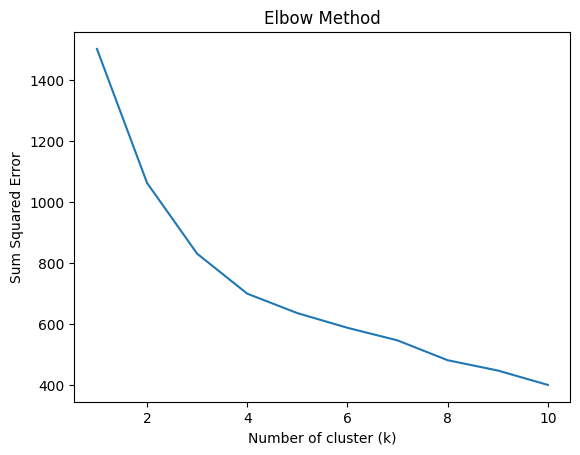

In [149]:
# Have copied this boilerplate code from the k-means notebook. This would allow us to select the ideal value of k

g=sns.lineplot(x=range(1,11), y=sse)

g.set(xlabel ="Number of cluster (k)",
	ylabel = "Sum Squared Error",
	title ='Elbow Method')

plt.show()

We would be selecting k = 3, since at this point the drop is comparitively less steep

In [150]:
# silhouette analysis
range_n_clusters = [2, 3, 4, 5, 6, 7, 8, 9, 10]

for num_clusters in range_n_clusters:

    # intialise kmeans
    km = KMeans(n_clusters=num_clusters, max_iter=50, random_state=42)
    km.fit(df_scaled)

    cluster_labels = km.labels_

    # silhouette score
    silhouette_avg = silhouette_score(df_scaled, cluster_labels)
    print("For n_clusters={0}, the silhouette score is {1}".format(num_clusters, silhouette_avg))

For n_clusters=2, the silhouette score is 0.2662961111870726
For n_clusters=3, the silhouette score is 0.285600988953231
For n_clusters=4, the silhouette score is 0.2880471307804802
For n_clusters=5, the silhouette score is 0.30088229124112015
For n_clusters=6, the silhouette score is 0.23565028812238528
For n_clusters=7, the silhouette score is 0.2479313491087983
For n_clusters=8, the silhouette score is 0.20198237114728412
For n_clusters=9, the silhouette score is 0.19230727869997855
For n_clusters=10, the silhouette score is 0.19624516158796698


The above results actually show a marginal improvment for k = 5 as compared to k=5. The silhoutte scores seem to be quite less though that is expected since socio-economic parameters of countries are continuous and not sharply different.

Still, i would be considering k=3 since its better to class countries into developing, developed and under-developing countries.

In [151]:
# instantiating KMeans as km

km = KMeans(n_clusters=3, random_state=42)

In [152]:
pred = km.fit_predict(df_scaled)

In [153]:
# Assigning cluster_id as the value given by pred

df['cluster_id'] = pred

In [154]:
km.cluster_centers_

array([[-0.39328196, -0.03058375, -0.20617903,  0.01956247, -0.25093021,
        -0.00578315,  0.22676244, -0.40257862, -0.35583225],
       [-0.82744866,  0.64507985,  0.72741122,  0.19063895,  1.48424268,
        -0.48492064,  1.07957853, -0.79187687,  1.61599536],
       [ 1.41356446, -0.45761494, -0.18789794, -0.18989721, -0.70783863,
         0.39898875, -1.29703104,  1.40287396, -0.61276131]])

In [155]:
# cluster-wise analysis of cluster_id

df.groupby('cluster_id').mean(numeric_only=True)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster_id,,,,,,,,,
0,22.456977,40.273128,6.251047,47.362394,12321.744186,7.720884,72.566279,2.340349,6461.767442
1,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
2,95.106667,28.602444,6.301111,42.306667,3539.844444,11.986778,59.055556,5.065333,1766.711111


In [156]:
# Checking India's cluster information

df[df['country'] == 'India'][['country', 'cluster_id']]

,country,cluster_id
69,India,0


In [157]:
# creating an underdeveloped countries dataframe

under_developed_df = df[df['cluster_id'] == 2]
under_developed_df

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster_id
0,Afghanistan,90.2,10.00,7.58,44.9,1610,9.440,56.2,5.82,553,2
3,Angola,119.0,62.30,2.85,42.9,5900,22.400,60.1,6.16,3530,2
17,Benin,111.0,23.80,4.10,37.2,1820,0.885,61.8,5.36,758,2
25,Burkina Faso,116.0,19.20,6.74,29.6,1430,6.810,57.9,5.87,575,2
26,Burundi,93.6,8.92,11.60,39.2,764,12.300,57.7,6.26,231,2
28,Cameroon,108.0,22.20,5.13,27.0,2660,1.910,57.3,5.11,1310,2
31,Central African Republic,149.0,11.80,3.98,26.5,888,2.010,47.5,5.21,446,2
32,Chad,150.0,36.80,4.53,43.5,1930,6.390,56.5,6.59,897,2
36,Comoros,88.2,16.50,4.51,51.7,1410,3.870,65.9,4.75,769,2
37,"Congo, Dem. Rep.",116.0,41.10,7.91,49.6,609,20.800,57.5,6.54,334,2


In [158]:
# Sort them by highest child mortality and lowest GDP to get the top priority list

priority_list = under_developed_df.sort_values(by=['child_mort', 'gdpp'], ascending=[False, True])
priority_list

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster_id
66,Haiti,208.0,15.30,6.91,64.7,1500,5.450,32.1,3.33,662,2
132,Sierra Leone,160.0,16.80,13.10,34.5,1220,17.200,55.0,5.20,399,2
32,Chad,150.0,36.80,4.53,43.5,1930,6.390,56.5,6.59,897,2
31,Central African Republic,149.0,11.80,3.98,26.5,888,2.010,47.5,5.21,446,2
97,Mali,137.0,22.80,4.98,35.1,1870,4.370,59.5,6.55,708,2
113,Nigeria,130.0,25.30,5.07,17.4,5150,104.000,60.5,5.84,2330,2
112,Niger,123.0,22.20,5.16,49.1,814,2.550,58.8,7.49,348,2
3,Angola,119.0,62.30,2.85,42.9,5900,22.400,60.1,6.16,3530,2
37,"Congo, Dem. Rep.",116.0,41.10,7.91,49.6,609,20.800,57.5,6.54,334,2
25,Burkina Faso,116.0,19.20,6.74,29.6,1430,6.810,57.9,5.87,575,2


In [159]:
# Look at the top 5 countries needing aid

priority_list[['country', 'child_mort', 'income', 'gdpp']].head()

,country,child_mort,income,gdpp
66,Haiti,208.0,1500,662
132,Sierra Leone,160.0,1220,399
32,Chad,150.0,1930,897
31,Central African Republic,149.0,888,446
97,Mali,137.0,1870,708


In [160]:
aid_list = priority_list['country'].head().to_list()
aid_list

['Haiti', 'Sierra Leone', 'Chad', 'Central African Republic', 'Mali']

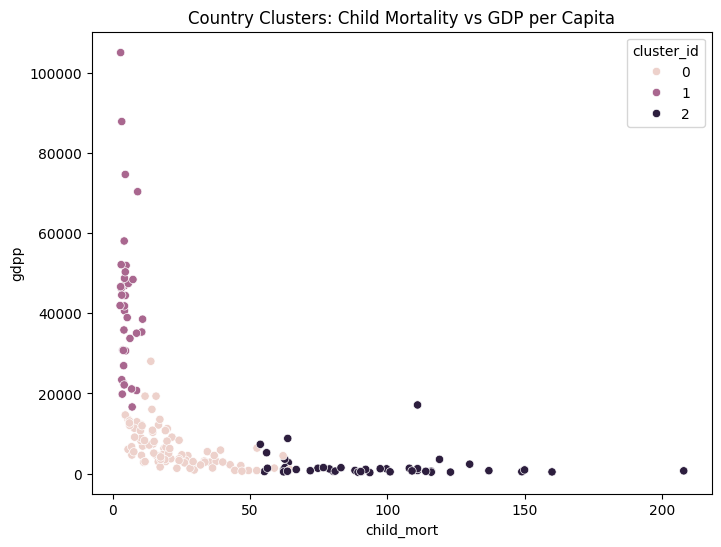

In [161]:
# Plotting the clusters using scatterplot of child mortality rate vs gdpp

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='child_mort', y='gdpp', hue='cluster_id')
plt.title('Country Clusters: Child Mortality vs GDP per Capita')
plt.show()

Above plot shows that to a greater extent the clustering seems to have done a decent job. However, we could see that there are some overlaps between the clusters based on the above 2 metrics. Probably the other variables might have influenced it as well.

The countries for whom the maximum priority should be are:

**Haiti, Sierra Leone, Chad, Central African Republic, Mali**